**Goal:** build the one operation the Transformer is made from. You will write **scaled dot-product
attention** from scratch and check it against PyTorch's own, read an interpretable **self-attention**
matrix, see why the **sqrt(d_k)** scale is there, and then train a single self-attention layer to solve a
**long-range lookup** that a non-attentive baseline cannot. Everything runs on CPU in about three
seconds. Pairs with the concept note [Attention Mechanisms](l21_concept_attention.qmd).

> **Previously:** L20 -- Autoencoders & Representation Learning (features without labels)  |  **Next:** L22 -- The Transformer Architecture

> This page is the read-only view. To run the lab, open the notebook
> (`l21_lab_attention.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

A word in a sentence often depends on another word far away ("the trophy did not fit in the suitcase
because **it** was too small" -- *it* is the suitcase). Passing information hand-to-hand down a chain
loses that thread over distance. **Attention** lets each position reach straight to any other and pull in
what it needs, weighted by relevance. It is one formula. We build it, look at what it does, and prove it
earns its keep on a task that needs exactly this kind of reach.

## Setup

Two cells: the first installs, the second imports and seeds. There is no dataset to download -- every
tensor in this lab is built in the notebook.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships these, so this is effectively a no-op there.
%pip install -q torch matplotlib
# local, in a terminal (not in the notebook):  uv add torch matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS (safe to re-run without re-installing)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)
print("setup ready -", "GPU" if torch.cuda.is_available() else "CPU")

setup ready - CPU


~~~text
setup ready - CPU
~~~

## Step 1: Build Scaled Dot-Product Attention

Attention has three inputs. Every position emits a **query** (what it is looking for), a **key** (what it
offers as a match), and a **value** (what it passes on if matched). A query is compared against every key
by a **dot product** (large = similar); those scores go through a **softmax** to become **attention
weights** that sum to 1; the output is the values blended by those weights. One scale factor,
`1 / sqrt(d_k)`, keeps the scores from blowing up (Step 3 shows why). That is the whole formula:

$$\text{attention}(Q, K, V) = \operatorname{softmax}\!\left(\frac{Q K^{\top}}{\sqrt{d_k}}\right) V$$

In [3]:
def attention(Q, K, V):
    """softmax(Q K^T / sqrt(d_k)) V. Returns the output and the attention weights."""
    d_k = Q.shape[-1]
    scores = (Q @ K.transpose(-2, -1)) / (d_k ** 0.5)     # (..., Lq, Lk)
    weights = scores.softmax(dim=-1)                       # each row sums to 1
    return weights @ V, weights

torch.manual_seed(0)
Lq, Lk, d_k, d_v = 3, 4, 8, 5
Q = torch.randn(Lq, d_k); K = torch.randn(Lk, d_k); V = torch.randn(Lk, d_v)
out, w = attention(Q, K, V)
print("output shape:", tuple(out.shape))
print("attention weights (one row per query, each sums to 1):")
print(w.numpy())
print("row sums:", w.sum(dim=-1).numpy())
ref = F.scaled_dot_product_attention(Q, K, V)
print("matches torch's built-in scaled_dot_product_attention:", torch.allclose(out, ref, atol=1e-6))

output shape: (3, 5)
attention weights (one row per query, each sums to 1):
[[0.152 0.039 0.727 0.082]
 [0.298 0.17  0.362 0.17 ]
 [0.325 0.147 0.441 0.088]]
row sums: [1. 1. 1.]
matches torch's built-in scaled_dot_product_attention: True


~~~text
output shape: (3, 5)
attention weights (one row per query, each sums to 1):
[[0.152 0.039 0.727 0.082]
 [0.298 0.17  0.362 0.17 ]
 [0.325 0.147 0.441 0.088]]
row sums: [1. 1. 1.]
matches torch's built-in scaled_dot_product_attention: True
~~~

Three queries, four key/value pairs: each query produces a row of four weights that sum to 1, and the
output blends the four 5-dimensional values into three. Our eight lines match PyTorch's optimized
`scaled_dot_product_attention` exactly -- that is the entire mechanism.

## Step 2: Self-Attention Is Interpretable

It becomes **self**-attention when the queries, keys, and values all come from the **same** sequence --
every token attends to every token, including itself. In the simplest case each token *is* its own query,
key, and value (`Q = K = V = X`), so a token attends to the tokens it most resembles. Build four tokens
as two near-duplicate pairs and read the matrix:

In [4]:
X = torch.tensor([
    [3.0, 0.6, 0.0, 0.0],     # token 0  -- 'cat'
    [3.0, 0.0, 0.0, 0.0],     # token 1  -- 'kitten' (nearly the same as token 0)
    [0.0, 0.0, 3.0, 0.6],     # token 2  -- 'car'
    [0.0, 0.0, 3.0, 0.0],     # token 3  -- 'truck'  (nearly the same as token 2)
])
ctx, A = attention(X, X, X)         # self-attention: query, key, value all come from X
print("attention matrix (row i = how much token i attends to each token):")
print(A.numpy())

attention matrix (row i = how much token i attends to each token):
[[0.539 0.451 0.005 0.005]
 [0.495 0.495 0.005 0.005]
 [0.005 0.005 0.539 0.451]
 [0.005 0.005 0.495 0.495]]


~~~text
attention matrix (row i = how much token i attends to each token):
[[0.539 0.451 0.005 0.005]
 [0.495 0.495 0.005 0.005]
 [0.005 0.005 0.539 0.451]
 [0.005 0.005 0.495 0.495]]
~~~

The matrix is two clean blocks. `cat` splits its attention between itself and `kitten` (0.54 and 0.45)
and all but ignores `car`/`truck` (0.005); the vehicle pair does the mirror image. Attention routed each
token to the tokens it resembles -- a content-based lookup, no rules written by hand. The same picture as
a heatmap:

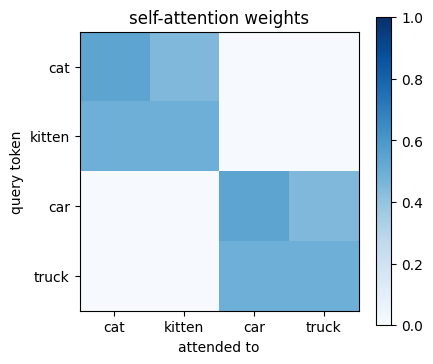

In [5]:
labels = ["cat", "kitten", "car", "truck"]
plt.figure(figsize=(4.5, 4))
plt.imshow(A.numpy(), cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(4), labels); plt.yticks(range(4), labels)
plt.xlabel("attended to"); plt.ylabel("query token")
plt.title("self-attention weights"); plt.colorbar(); plt.show()

In a real layer the three roles are not the raw token -- three learned matrices `Wq`, `Wk`, `Wv` first
project each token into a query, a key, and a value. You will train those in Step 4.

## Step 3: Why Divide by sqrt(d_k)

The scale factor is not cosmetic. A dot product of two `d_k`-dimensional vectors is a sum of `d_k` terms,
so its size grows with `d_k`. Feed large scores to a softmax and it **saturates**: almost all the weight
lands on one key and the rest get nothing -- and a saturated softmax has almost no gradient, so the layer
stops learning. Dividing by `sqrt(d_k)` cancels that growth. Watch the largest attention weight (averaged
over many random queries against 8 keys) as the dimension climbs:

In [6]:
torch.manual_seed(0)
print(f"{'d_k':>5} {'unscaled max weight':>20} {'scaled max weight':>18}")
for d_k in [4, 16, 64, 256]:
    q = torch.randn(2000, 1, d_k)                 # 2000 trials, one query each
    Kk = torch.randn(2000, 8, d_k)                # 8 keys to attend over
    raw = (q @ Kk.transpose(-2, -1)).squeeze(1)   # (2000, 8) dot products
    mw_raw = raw.softmax(-1).max(-1).values.mean().item()
    mw_scaled = (raw / d_k ** 0.5).softmax(-1).max(-1).values.mean().item()
    print(f"{d_k:>5} {mw_raw:>20.3f} {mw_scaled:>18.3f}")

  d_k  unscaled max weight  scaled max weight
    4                0.529              0.344
   16                0.748              0.359
   64                0.875              0.361
  256                0.938              0.362


~~~text
  d_k  unscaled max weight  scaled max weight
    4                0.529              0.344
   16                0.748              0.359
   64                0.875              0.361
  256                0.938              0.362
~~~

Unscaled, the top weight climbs from 0.53 toward 0.94 as `d_k` grows -- by 256 dimensions the softmax has
collapsed onto a single key. Scaled, it holds steady near 0.36 at every dimension. That one `sqrt(d_k)`
keeps attention smooth enough to train.

## Step 4: The Payoff -- a Long-Range Lookup

Now make attention earn its keep. Each sequence is a **query** token (position 0) followed by seven
**memory slots**; every slot has a distinct **key** and a random **value**. The query's key matches
exactly one slot, and the answer is that slot's value. The matching slot can sit anywhere, so the model
must search the whole sequence by content -- a **long-range** dependency.

In [7]:
def make_recall_dataset(n, seq_len=8, n_keys=10, n_vals=6, seed=0):
    """Position 0 is a QUERY (its key matches one memory slot); positions 1.. are memory
    slots with distinct keys + random values. Target = the matched slot's value."""
    g = torch.Generator().manual_seed(seed)
    n_slots = seq_len - 1
    PAD_VAL = n_vals
    keys = torch.zeros(n, seq_len, dtype=torch.long)
    vals = torch.full((n, seq_len), PAD_VAL, dtype=torch.long)
    y = torch.zeros(n, dtype=torch.long)
    for i in range(n):
        slot_keys = torch.randperm(n_keys, generator=g)[:n_slots]
        slot_vals = torch.randint(n_vals, (n_slots,), generator=g)
        tgt = torch.randint(n_slots, (1,), generator=g).item()
        keys[i, 1:] = slot_keys
        vals[i, 1:] = slot_vals
        keys[i, 0] = slot_keys[tgt]      # the query asks for this slot's key
        y[i] = slot_vals[tgt]            # answer = that slot's value
    return keys, vals, y

ktr, vtr, ytr = make_recall_dataset(4000, seed=0)
kte, vte, yte = make_recall_dataset(1000, seed=1)
data = (ktr, vtr, ytr, kte, vte, yte)
print("train", tuple(ktr.shape), "test", tuple(kte.shape), "| seq_len", ktr.shape[1])
print("example 0 -> query key:", kte[0, 0].item(), "| slot keys:", kte[0, 1:].tolist())
print("            slot values:", vte[0, 1:].tolist(), "| answer:", yte[0].item())

train (4000, 8) test (1000, 8) | seq_len 8
example 0 -> query key: 9 | slot keys: [5, 6, 1, 2, 0, 8, 9]
            slot values: [0, 2, 3, 4, 5, 1, 0] | answer: 0


~~~text
train (4000, 8) test (1000, 8) | seq_len 8
example 0 -> query key: 9 | slot keys: [5, 6, 1, 2, 0, 8, 9]
            slot values: [0, 2, 3, 4, 5, 1, 0] | answer: 0
~~~

Each discrete key/value symbol becomes a learned vector with `nn.Embedding` (a **token embedding**: a
lookup table the network trains). The self-attention model projects every token to a query/key/value,
attends, and reads out at the query position. The **baseline** sees the same tokens but **mean-pools**
them -- averaging the positions away, so it cannot tell which value goes with the query's key.

In [8]:
class SelfAttnRecall(nn.Module):
    def __init__(self, n_keys, n_vals, d=32):
        super().__init__()
        self.key_emb = nn.Embedding(n_keys, d)
        self.val_emb = nn.Embedding(n_vals + 1, d)        # +1 for the query's PAD value
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d); self.Wv = nn.Linear(d, d)
        self.out = nn.Linear(d, n_vals)
    def forward(self, keys, vals, return_attn=False):
        X = self.key_emb(keys) + self.val_emb(vals)       # (B, L, d)
        ctx, w = attention(self.Wq(X), self.Wk(X), self.Wv(X))
        logits = self.out(ctx[:, 0])                      # read out at the query position
        return (logits, w) if return_attn else logits

class MeanPoolBaseline(nn.Module):
    def __init__(self, n_keys, n_vals, d=32):
        super().__init__()
        self.key_emb = nn.Embedding(n_keys, d)
        self.val_emb = nn.Embedding(n_vals + 1, d)
        self.mlp = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, n_vals))
    def forward(self, keys, vals):
        X = self.key_emb(keys) + self.val_emb(vals)
        return self.mlp(X.mean(dim=1))                    # pools positions -> cannot route

def train_model(model, data, epochs=20, bs=256):
    ktr, vtr, ytr, kte, vte, yte = data
    opt = torch.optim.Adam(model.parameters(), lr=1e-3); loss_fn = nn.CrossEntropyLoss()
    n = len(ytr)
    for epoch in range(epochs):
        g = torch.Generator().manual_seed(epoch)
        perm = torch.randperm(n, generator=g)
        model.train()
        for s in range(0, n, bs):
            b = perm[s:s + bs]
            opt.zero_grad(); loss_fn(model(ktr[b], vtr[b]), ytr[b]).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return (model(kte, vte).argmax(1) == yte).float().mean().item()

torch.manual_seed(0)
attn_model = SelfAttnRecall(n_keys=10, n_vals=6)
acc_attn = train_model(attn_model, data)

torch.manual_seed(0)
base_model = MeanPoolBaseline(n_keys=10, n_vals=6)
acc_base = train_model(base_model, data)

print(f"self-attention test accuracy: {acc_attn:.4f}")
print(f"mean-pool baseline accuracy:  {acc_base:.4f}   (chance = {1/6:.4f})")

self-attention test accuracy: 1.0000
mean-pool baseline accuracy:  0.3730   (chance = 0.1667)


~~~text
self-attention test accuracy: 1.0000
mean-pool baseline accuracy:  0.3730   (chance = 0.1667)
~~~

Attention solves it **perfectly**; the baseline, with the exact same information but no way to route it,
manages only **0.37** -- above chance (it can lean on which values are present) but nowhere near binding
the query to the right one. The difference is selective focus. Look at where the trained attention points
for one test sequence:

query-position attention weights: [0.    0.016 0.005 0.    0.001 0.001 0.014 0.963]
matching slot is position: 7 | attention's argmax: 7


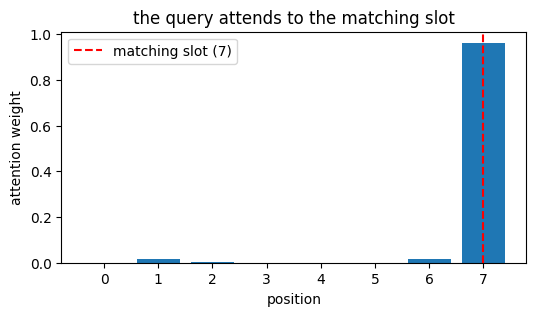

In [9]:
with torch.no_grad():
    _, w = attn_model(kte[:1], vte[:1], return_attn=True)
qrow = w[0, 0].numpy()                                    # the query position's attention over all slots
match = (kte[0, 1:] == kte[0, 0]).nonzero().item() + 1    # the slot whose key matches the query
print("query-position attention weights:", qrow)
print("matching slot is position:", match, "| attention's argmax:", qrow.argmax())

plt.figure(figsize=(6, 3))
plt.bar(range(len(qrow)), qrow)
plt.axvline(match, color="red", ls="--", label=f"matching slot ({match})")
plt.xlabel("position"); plt.ylabel("attention weight"); plt.legend()
plt.title("the query attends to the matching slot"); plt.show()

~~~text
query-position attention weights: [0.    0.016 0.005 0.    0.001 0.001 0.014 0.963]
matching slot is position: 7 | attention's argmax: 7
~~~

The query spends **0.963** of its attention on position 7 -- the one slot whose key it matches -- and
almost nothing elsewhere. It learned to *look up* the right value, wherever it sat.

In [10]:
# Your turn (warm-up): the attention weights for a batch are (batch, seq_len, seq_len) -- one
# L x L matrix per example. Predict the shape for ALL 1000 test sequences, then check.
# Uncomment and fill the blank:
# with torch.no_grad():
#     _, W = attn_model(kte, vte, return_attn=True)
# print("attention weights shape:", tuple(W.shape))     # expect (____, ____, ____)

The shape is `(1000, 8, 8)`: one 8x8 attention matrix for each of the 1000 test sequences (each of the 8
positions attends over all 8). That `seq_len x seq_len` cost is why long sequences are expensive -- it
grows with the **square** of the length.

## Your Turn

### Exercise 1 -- Attention is order-blind

Take one test example and record the model's prediction. Then make a copy with the seven memory slots
(positions 1..7) **shuffled** -- keep position 0, the query, fixed -- and predict again. Does the answer
change? What does that tell you about whether attention knows the order of its input?

**Hint:** build `perm = torch.randperm(7, generator=torch.Generator().manual_seed(7)) + 1`; clone
`kte[:1]` and `vte[:1]`, then set their slot positions to `kte[0, perm]` / `vte[0, perm]`; compare
`attn_model(...).argmax(1)` before and after.

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
prediction on original slot order: 0
prediction after shuffling slots:  0
same answer (order ignored): True
~~~

Shuffling the slots does not change the answer. Pure attention treats its input as a **set** -- it sums
over positions with no notion of their order. For this lookup that is exactly right (the answer does not
depend on slot order), but for language, where order is meaning ("dog bites man" vs "man bites dog"), the
model must be told the positions. That is **positional encoding**, and adding it is the Transformer's job
in L22.
</details>

### Exercise 2 -- Longer range

Does attention still cope when the matching slot can be twice as far away? Rebuild the recall task at
`seq_len=16` (fifteen memory slots; raise `n_keys` to 20 so the keys stay distinct) and retrain a fresh
self-attention model. Report its test accuracy.

**Hint:** `make_recall_dataset(4000, seq_len=16, n_keys=20, seed=0)` for train and `seed=1` for test;
pack them into a `data` tuple as in Step 4; `torch.manual_seed(0)` before building
`SelfAttnRecall(n_keys=20, n_vals=6)`; then `train_model(model, data)`.

In [12]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
seq_len=16 self-attention test accuracy: 1.0000
~~~

Doubling the sequence length does not faze it -- attention still routes the query straight to the
matching slot, wherever it sits among the fifteen. A step-by-step model would have to carry the right
value across up to fifteen positions without losing it; attention reaches any position in a **single
hop**. That one-hop path to everything is why attention handles long-range dependencies so well.
</details>

## Summary

- **Scaled dot-product attention** is one formula: `softmax(Q K^T / sqrt(d_k)) V`. Each token emits a
  **query**, **key**, and **value**; the query scores against every key, a softmax turns the scores into
  **attention weights** (each row sums to 1), and the output blends the values. Our from-scratch version
  matched PyTorch's built-in exactly.
- In **self-attention** the query, key, and value all come from the same sequence. With `Q=K=V=X` a token
  attends to the tokens it resembles -- the matrix split into clean blocks.
- The **sqrt(d_k)** scale stops the softmax saturating in high dimension (top weight held near 0.36
  instead of climbing to 0.94 at `d_k=256`), keeping the layer trainable.
- On a **long-range lookup**, a single self-attention layer scored **1.0000** while a mean-pool baseline
  -- same information, no routing -- got **0.3730**; the trained attention put **0.963** of its weight on
  the one matching slot, anywhere in the sequence (Ex2: still 1.0000 at length 16).
- Attention is **order-blind** (Ex1): it treats its input as a set, so sequence order has to be added
  separately. Next (L22): **positional encoding**, **multi-head** attention, and the residual + layer-norm
  blocks that stack these into the **Transformer**.